# Путешествие во времени (Time travel)

## Обзор (Review)

Мы рассмотрели причины для включения человека в цикл (human-in-the-loop):

1. **Согласование (Approval)** - Возможность прервать агента, показать состояние пользователю и получить подтверждение действия
2. **Отладка (Debugging)** - Возможность перемотки графа для воспроизведения или избежания проблем
3. **Редактирование (Editing)** - Возможность модификации состояния

Мы показали:
- Как точки останова (breakpoints) останавливают граф на конкретных узлах
- Как граф может прерывать себя динамически
- Процедуры продолжения после подтверждения или прямого редактирования состояния

## Цели (Goals)

Теперь продемонстрируем, как LangGraph [поддерживает отладку](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/time-travel/) через:
- Просмотр прошлых состояний
- Повторное выполнение (re-play) 
- Создание ответвлений (fork) из предыдущих состояний

Этот функционал мы называем **"путешествием во времени"** (time travel).

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

import os
api_key = os.getenv("GIGA_API_KEY")

llm = model = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.0,
    profanity_check = False,
    model="GigaChat",
)

==================================================================================================================

In [4]:
def multiply(a: int, b: int) -> int:
    """Умножает a на b.

    Args:
        a: первое целое число
        b: второе целое число
    """
    return a * b

# Будет использоваться как инструмент (tool)
def add(a: int, b: int) -> int:
    """Складывает a и b.

    Args:
        a: первое целое число
        b: второе целое число
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Делит a на b.

    Args:
        a: первое целое число
        b: второе целое число
    """
    return a / b

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

In [5]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

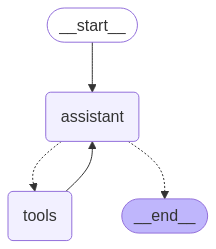

In [6]:
# Системное сообщение
sys_msg = SystemMessage(content="Вы помощник, выполняющий арифметические операции над входными данными.")

# Узел (node)
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Граф (graph)
builder = StateGraph(MessagesState)

# Определение узлов:
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Определение связей (edges):
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # Если последнее сообщение от assistant содержит вызов инструмента -> переход к tools
    # Если не содержит вызова инструмента -> переход к END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Отображение
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [7]:
# Входные данные (Input)
initial_input = {"messages": [HumanMessage(content="Умножь 2 на 3")]}

# Поток выполнения (Thread)
thread = {"configurable": {"thread_id": "1"}}

# Запускаем граф до первого прерывания
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Умножь 2 на 3
================================== Ai Message ==================================
Tool Calls:
  multiply (3777849e-06ae-41e4-a54e-fc0ebb828252)
 Call ID: 3777849e-06ae-41e4-a54e-fc0ebb828252
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

Результат умножения 2 на 3 равен 6.


## Просмотр истории (Browsing History)

Мы можем использовать метод `get_state` для проверки **текущего состояния** нашего графа, используя `thread_id`!

In [8]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Умножь 2 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': {'a': 2, 'b': 3}}, 'functions_state_id': '4a07ac54-c908-4023-8763-ed51dce00cf6'}, response_metadata={'token_usage': {'prompt_tokens': 238, 'completion_tokens': 30, 'total_tokens': 268, 'precached_prompt_tokens': 0}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': '1729e96a-7d9b-4570-a902-687c622dc8b4', 'x-session-id': 'daab5b3c-2287-4e7f-9e09-590baa2540a1', 'x-client-id': None}, 'finish_reason': 'function_call'}, id='1729e96a-7d9b-4570-a902-687c622dc8b4', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '3777849e-06ae-41e4-a54e-fc0ebb828252', 'type': 'tool_call'}]), ToolMessage(content='6', name='multiply', id='67a76e7c-6b5e-454c-9127-b2dafa2fa550', tool_call_id='3777849e-06ae-41e4-a54e-fc0ebb828252'), A

Мы также можем просматривать историю состояний нашего агента.

`get_state_history` позволяет получить состояние на всех предыдущих шагах.

In [10]:
all_states = [s for s in graph.get_state_history(thread)]
len(all_states)

5

Первый элемент - это текущее состояние, такое же, как мы получали через `get_state`.

In [27]:
all_states[-2]

StateSnapshot(values={'messages': [HumanMessage(content='Умножь 2 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00c72d-e05c-6257-8000-7e96bd83f524'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': '1', 'step': 0, 'parents': {}}, created_at='2025-03-29T07:53:13.920981+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00c72d-e054-6fa4-bfff-672025a6ecb6'}}, tasks=(PregelTask(id='6f19e059-cb3b-e727-7c65-3875e31341f8', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': {'a': 2, 'b': 3}}, 'functions_state_id': '4a07ac54-c908-4023-8763-ed51dce00cf6'}, response_metadata={'token_usage': {'prompt_tokens': 238, 'completion_tokens':

Всё описанное выше мы можем визуализировать:

![fig1.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb038211b544898570be3_time-travel1.png)

## Повторное выполнение (Replaying)

Мы можем перезапустить агента с любого из предыдущих шагов.

![fig2.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb038a0bd34b541c78fb8_time-travel2.png)

Давайте вернёмся к шагу, на котором был получен пользовательский ввод.

In [28]:
to_replay = all_states[-2]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Умножь 2 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00c72d-e05c-6257-8000-7e96bd83f524'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': '1', 'step': 0, 'parents': {}}, created_at='2025-03-29T07:53:13.920981+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00c72d-e054-6fa4-bfff-672025a6ecb6'}}, tasks=(PregelTask(id='6f19e059-cb3b-e727-7c65-3875e31341f8', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': {'a': 2, 'b': 3}}, 'functions_state_id': '4a07ac54-c908-4023-8763-ed51dce00cf6'}, response_metadata={'token_usage': {'prompt_tokens': 238, 'completion_tokens':

In [29]:
to_replay.values

{'messages': [HumanMessage(content='Умножь 2 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]}

In [30]:
to_replay.next

('assistant',)

Мы также получаем конфигурацию (config), которая содержит checkpoint_id и thread_id.

In [31]:
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f00c72d-e05c-6257-8000-7e96bd83f524'}}

Для повторного выполнения просто передаем конфигурацию (config) агенту!

Граф знает, что эта контрольная точка (checkpoint) уже была выполнена.

Он просто повторно воспроизводит выполнение с этой точки.

In [32]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Умножь 2 на 3
================================== Ai Message ==================================
Tool Calls:
  multiply (1c6078c2-6326-4d06-850a-ea10b1c579eb)
 Call ID: 1c6078c2-6326-4d06-850a-ea10b1c579eb
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

Результат умножения 2 на 3 равен 6.


Мы можем увидеть текущее состояние после повторного запуска агента.

==============================================================================================================

## Ветвление (Forking)

Что если мы хотим выполнить с того же шага, но с другими входными данными.

Это называется ветвлением.

![fig3.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb038f89f2d847ee5c336_time-travel3.png)

In [35]:
to_fork = all_states[-2]
to_fork.values["messages"]

[HumanMessage(content='Умножь 2 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]

In [36]:
to_fork.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f00c72d-e05c-6257-8000-7e96bd83f524'}}

## Модификация состояния в точке ветвления

Изменяем состояние в этой контрольной точке с помощью `update_state`, указав `checkpoint_id`.

Принцип работы редьюсера для `messages`:
* Сообщения добавляются (append), если не указан ID
* Для перезаписи сообщения необходимо указать его ID

Для перезаписи используем ID сообщения: `to_fork.values["messages"].id`

In [37]:
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(content='Умножь 5 на 3', 
                             id=to_fork.values["messages"][0].id)]},
)

In [38]:
fork_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f00c7e9-1858-6491-8001-e03f66eb08f7'}}

Это создает новую контрольную точку ветвления (forked checkpoint).

Однако метаданные (например, следующий шаг) сохраняются!

Текущее состояние агента обновилось согласно нашей ветке.

In [40]:
all_states = [state for state in graph.get_state_history(thread) ]
all_states[0].values["messages"]

[HumanMessage(content='Умножь 5 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]

In [41]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Умножь 5 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00c7e9-1858-6491-8001-e03f66eb08f7'}}, metadata={'source': 'update', 'writes': {'__start__': {'messages': [HumanMessage(content='Умножь 5 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52')]}}, 'thread_id': '1', 'step': 1, 'parents': {}, 'checkpoint_ns': '', 'checkpoint_id': '1f00c72d-e05c-6257-8000-7e96bd83f524'}, created_at='2025-03-29T09:16:59.534452+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f00c72d-e05c-6257-8000-7e96bd83f524'}}, tasks=(PregelTask(id='01a121d1-18c5-be31-b594-f24f99a6c64f', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),))

Теперь при стриминге граф понимает, что эта контрольная точка не выполнялась.

---

Следовательно, граф выполняет вычисления с нуля, а не просто воспроизводит предыдущие шаги.

In [42]:
for event in graph.stream(None, fork_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Умножь 5 на 3
================================== Ai Message ==================================
Tool Calls:
  multiply (9dfbbdb9-7d7e-45a5-bad2-4334cb294265)
 Call ID: 9dfbbdb9-7d7e-45a5-bad2-4334cb294265
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

Результат умножения 5 на 3 равен 15.


In [43]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Умножь 5 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': {'a': 5, 'b': 3}}, 'functions_state_id': '00c7f51e-9c20-41bc-8fb8-830f6d245c2c'}, response_metadata={'token_usage': {'prompt_tokens': 238, 'completion_tokens': 30, 'total_tokens': 268, 'precached_prompt_tokens': 0}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': 'd8bffd68-22a5-4d88-954e-66d8523b5da1', 'x-session-id': 'f1e4703b-2808-4cf5-b3d3-07fa030f87e1', 'x-client-id': None}, 'finish_reason': 'function_call'}, id='d8bffd68-22a5-4d88-954e-66d8523b5da1', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 3}, 'id': '9dfbbdb9-7d7e-45a5-bad2-4334cb294265', 'type': 'tool_call'}]), ToolMessage(content='15', name='multiply', id='a2569722-a8b7-4c93-bb8b-d90f198747d7', tool_call_id='9dfbbdb9-7d7e-45a5-bad2-4334cb294265'), 

In [44]:
graph.get_state({'configurable': {'thread_id': '1'}}).values

{'messages': [HumanMessage(content='Умножь 5 на 3', additional_kwargs={}, response_metadata={}, id='264af188-5666-46f8-b439-6219c8af3a52'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': {'a': 5, 'b': 3}}, 'functions_state_id': '00c7f51e-9c20-41bc-8fb8-830f6d245c2c'}, response_metadata={'token_usage': {'prompt_tokens': 238, 'completion_tokens': 30, 'total_tokens': 268, 'precached_prompt_tokens': 0}, 'model_name': 'GigaChat:1.0.26.20', 'x_headers': {'x-request-id': 'd8bffd68-22a5-4d88-954e-66d8523b5da1', 'x-session-id': 'f1e4703b-2808-4cf5-b3d3-07fa030f87e1', 'x-client-id': None}, 'finish_reason': 'function_call'}, id='d8bffd68-22a5-4d88-954e-66d8523b5da1', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 3}, 'id': '9dfbbdb9-7d7e-45a5-bad2-4334cb294265', 'type': 'tool_call'}]),
  ToolMessage(content='15', name='multiply', id='a2569722-a8b7-4c93-bb8b-d90f198747d7', tool_call_id='9dfbbdb9-7d7e-45a5-bad2-4334cb294265'),
  AIMessage(conte